# 1 - Visao geral dos dados

Este notebook apresenta a inspecao inicial da instancia do dataset 3W da Petrobras, com foco em estrutura, tipos, valores ausentes, distribuicoes basicas e visualizacao temporal das variaveis.


## 1. Ambiente

Bibliotecas usadas no fluxo:

- `pandas`, `numpy`
- `matplotlib`, `seaborn`
- `scikit-learn`
- `PyTorch` como framework de Deep Learning

Se `pyarrow` e `torch` nao estiverem instalados no ambiente do notebook, habilite a linha abaixo e execute a celula:

```python
# %pip install pyarrow torch
```

In [6]:
%pip install pyarrow torch

Note: you may need to restart the kernel to use updated packages.


In [7]:
from __future__ import annotations

from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


In [8]:
try:
    #mantem a celula funcional mesmo se o torch nao estiver instalado
    import torch
except ModuleNotFoundError:
    torch = None

#padroniza o estilo visual dos graficos do notebook
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 16

#printa as versoes para facilitar reproducao do ambiente
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"torch: {torch.__version__}" if torch is not None else "torch: nao instalado")


pandas: 2.3.3
numpy: 1.26.4
torch: 2.2.2


## 2. Aquisicao dos dados

O notebook usa exclusivamente a copia local do projeto oficial em `3W/dataset/`.
A celula de carga procura arquivos Parquet nessa estrutura e seleciona a primeira instancia disponivel para a exploracao.

Observacao importante: o 3W e um dataset composto por varias instancias temporais. Para a exploracao inicial e para a etapa de preparacao para LSTM, este notebook trabalha com uma unica instancia temporal por vez.

In [9]:
PROJECT_ROOT = Path.cwd()
LOCAL_3W_DIR = PROJECT_ROOT / "3W"
LOCAL_DATASET_DIR = LOCAL_3W_DIR / "dataset"


def resolve_parquet_file() -> Path:
    #garante que a estrutura esperada do dataset exista localmente
    if not LOCAL_DATASET_DIR.exists():
        raise FileNotFoundError(
            f"Pasta nao encontrada: {LOCAL_DATASET_DIR}. Esperado um clone local em 3W/dataset/."
        )

    #procura instancias parquet em toda a arvore do dataset
    local_files = sorted(LOCAL_DATASET_DIR.rglob("*.parquet"))
    if not local_files:
        raise FileNotFoundError(
            f"Nenhum arquivo .parquet foi encontrado em {LOCAL_DATASET_DIR}."
        )

    print(f"Usando arquivo local: {local_files[0]}")
    return local_files[0]


#carrega a primeira instancia encontrada para a analise exploratoria
parquet_file = resolve_parquet_file()
df = pd.read_parquet(parquet_file)
print(f"Shape inicial: {df.shape}")
print(f"Arquivo analisado: {parquet_file}")


Usando arquivo local: /Users/tiagoriosdarocha/Desktop/lstm-w3/versao1/3W/dataset/0/WELL-00001_20170201010207.parquet
Shape inicial: (21474, 29)
Arquivo analisado: /Users/tiagoriosdarocha/Desktop/lstm-w3/versao1/3W/dataset/0/WELL-00001_20170201010207.parquet


In [10]:
#normaliza o eixo temporal, esteja ele em coluna ou no indice
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.set_index("timestamp")
else:
    df.index = pd.to_datetime(df.index, errors="coerce")

#ordena a serie e explicita o nome do indice temporal
df = df.sort_index()
df.index.name = "timestamp"

print("Periodo coberto:")
print(df.index.min(), "->", df.index.max())
print("Colunas disponiveis:")
print(df.columns.tolist())


Periodo coberto:
2017-02-01 01:02:07 -> 2017-02-01 07:00:00
Colunas disponiveis:
['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'class', 'state']


## 3. Analise exploratoria

Nesta etapa exibimos amostras do dataframe, informacoes estruturais, estatisticas descritivas, tipos de dados e presenca de valores ausentes.

In [11]:
df.head()

,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,class,state
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-02-01 01:02:07,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.64463,NaN,0.0,119.0781,<NA>,<NA>
2017-02-01 01:02:08,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.63828,NaN,0.0,119.0781,<NA>,<NA>
2017-02-01 01:02:09,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.63194,NaN,0.0,119.0781,<NA>,<NA>
2017-02-01 01:02:10,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.62558,NaN,0.0,119.0781,<NA>,<NA>
2017-02-01 01:02:11,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.61923,NaN,0.0,119.0781,<NA>,<NA>


In [12]:
#usa StringIO para capturar a saida do info como texto formatado
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21474 entries, 2017-02-01 01:02:07 to 2017-02-01 07:00:00
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ABER-CKGL      0 non-null      float64
 1   ABER-CKP       0 non-null      float64
 2   ESTADO-DHSV    21474 non-null  float64
 3   ESTADO-M1      21474 non-null  float64
 4   ESTADO-M2      21474 non-null  float64
 5   ESTADO-PXO     21474 non-null  float64
 6   ESTADO-SDV-GL  21474 non-null  float64
 7   ESTADO-SDV-P   21474 non-null  float64
 8   ESTADO-W1      21474 non-null  float64
 9   ESTADO-W2      21474 non-null  float64
 10  ESTADO-XO      21474 non-null  float64
 11  P-ANULAR       21474 non-null  float64
 12  P-JUS-BS       0 non-null      float64
 13  P-JUS-CKGL     21474 non-null  float64
 14  P-JUS-CKP      0 non-null      float64
 15  P-MON-CKGL     0 non-null      float64
 16  P-MON-CKP      21474 non-null  float64
 17  P-MON-SDV-P    

In [13]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ABER-CKGL,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ABER-CKP,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESTADO-DHSV,21474.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ESTADO-M1,21474.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ESTADO-M2,21474.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ESTADO-PXO,21474.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ESTADO-SDV-GL,21474.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ESTADO-SDV-P,21474.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ESTADO-W1,21474.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ESTADO-W2,21474.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
#resume tipos e volume de faltantes por coluna
null_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "null_count": df.isna().sum(),
        "null_pct": (df.isna().mean() * 100).round(2),
    }
).sort_values(["null_count", "dtype"], ascending=[False, True])
null_summary


,dtype,null_count,null_pct
ABER-CKGL,float64,21474,100.00
ABER-CKP,float64,21474,100.00
P-JUS-BS,float64,21474,100.00
P-JUS-CKP,float64,21474,100.00
P-MON-CKGL,float64,21474,100.00
P-MON-SDV-P,float64,21474,100.00
PT-P,float64,21474,100.00
QBS,float64,21474,100.00
T-MON-CKP,float64,21474,100.00
class,Int16,3600,16.76


## 4. Visualizacao das variaveis

O dataset 3W contem, entre outras, as seguintes variaveis de sensores frequentemente usadas nas demonstracoes oficiais:

- `P-PDG`, `P-TPT`, `QGL`
- `T-PDG`, `T-TPT`
- `P-JUS-CKGL`, `P-JUS-CKP`, `P-MON-CKP`

O codigo abaixo seleciona automaticamente as principais variaveis disponiveis no arquivo carregado.

In [15]:
priority_columns = [
    "P-PDG",
    "P-TPT",
    "QGL",
    "T-PDG",
    "T-TPT",
    "P-JUS-CKGL",
    "P-JUS-CKP",
    "P-MON-CKP",
]

#lista todas as colunas numericas disponiveis para a exploracao
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
selected_plot_columns = [col for col in priority_columns if col in numeric_columns]

#se as colunas prioritarias nao existirem, usa um subconjunto numerico generico
if not selected_plot_columns:
    selected_plot_columns = numeric_columns[:6]

selected_plot_columns


['P-PDG',
 'P-TPT',
 'QGL',
 'T-PDG',
 'T-TPT',
 'P-JUS-CKGL',
 'P-JUS-CKP',
 'P-MON-CKP']

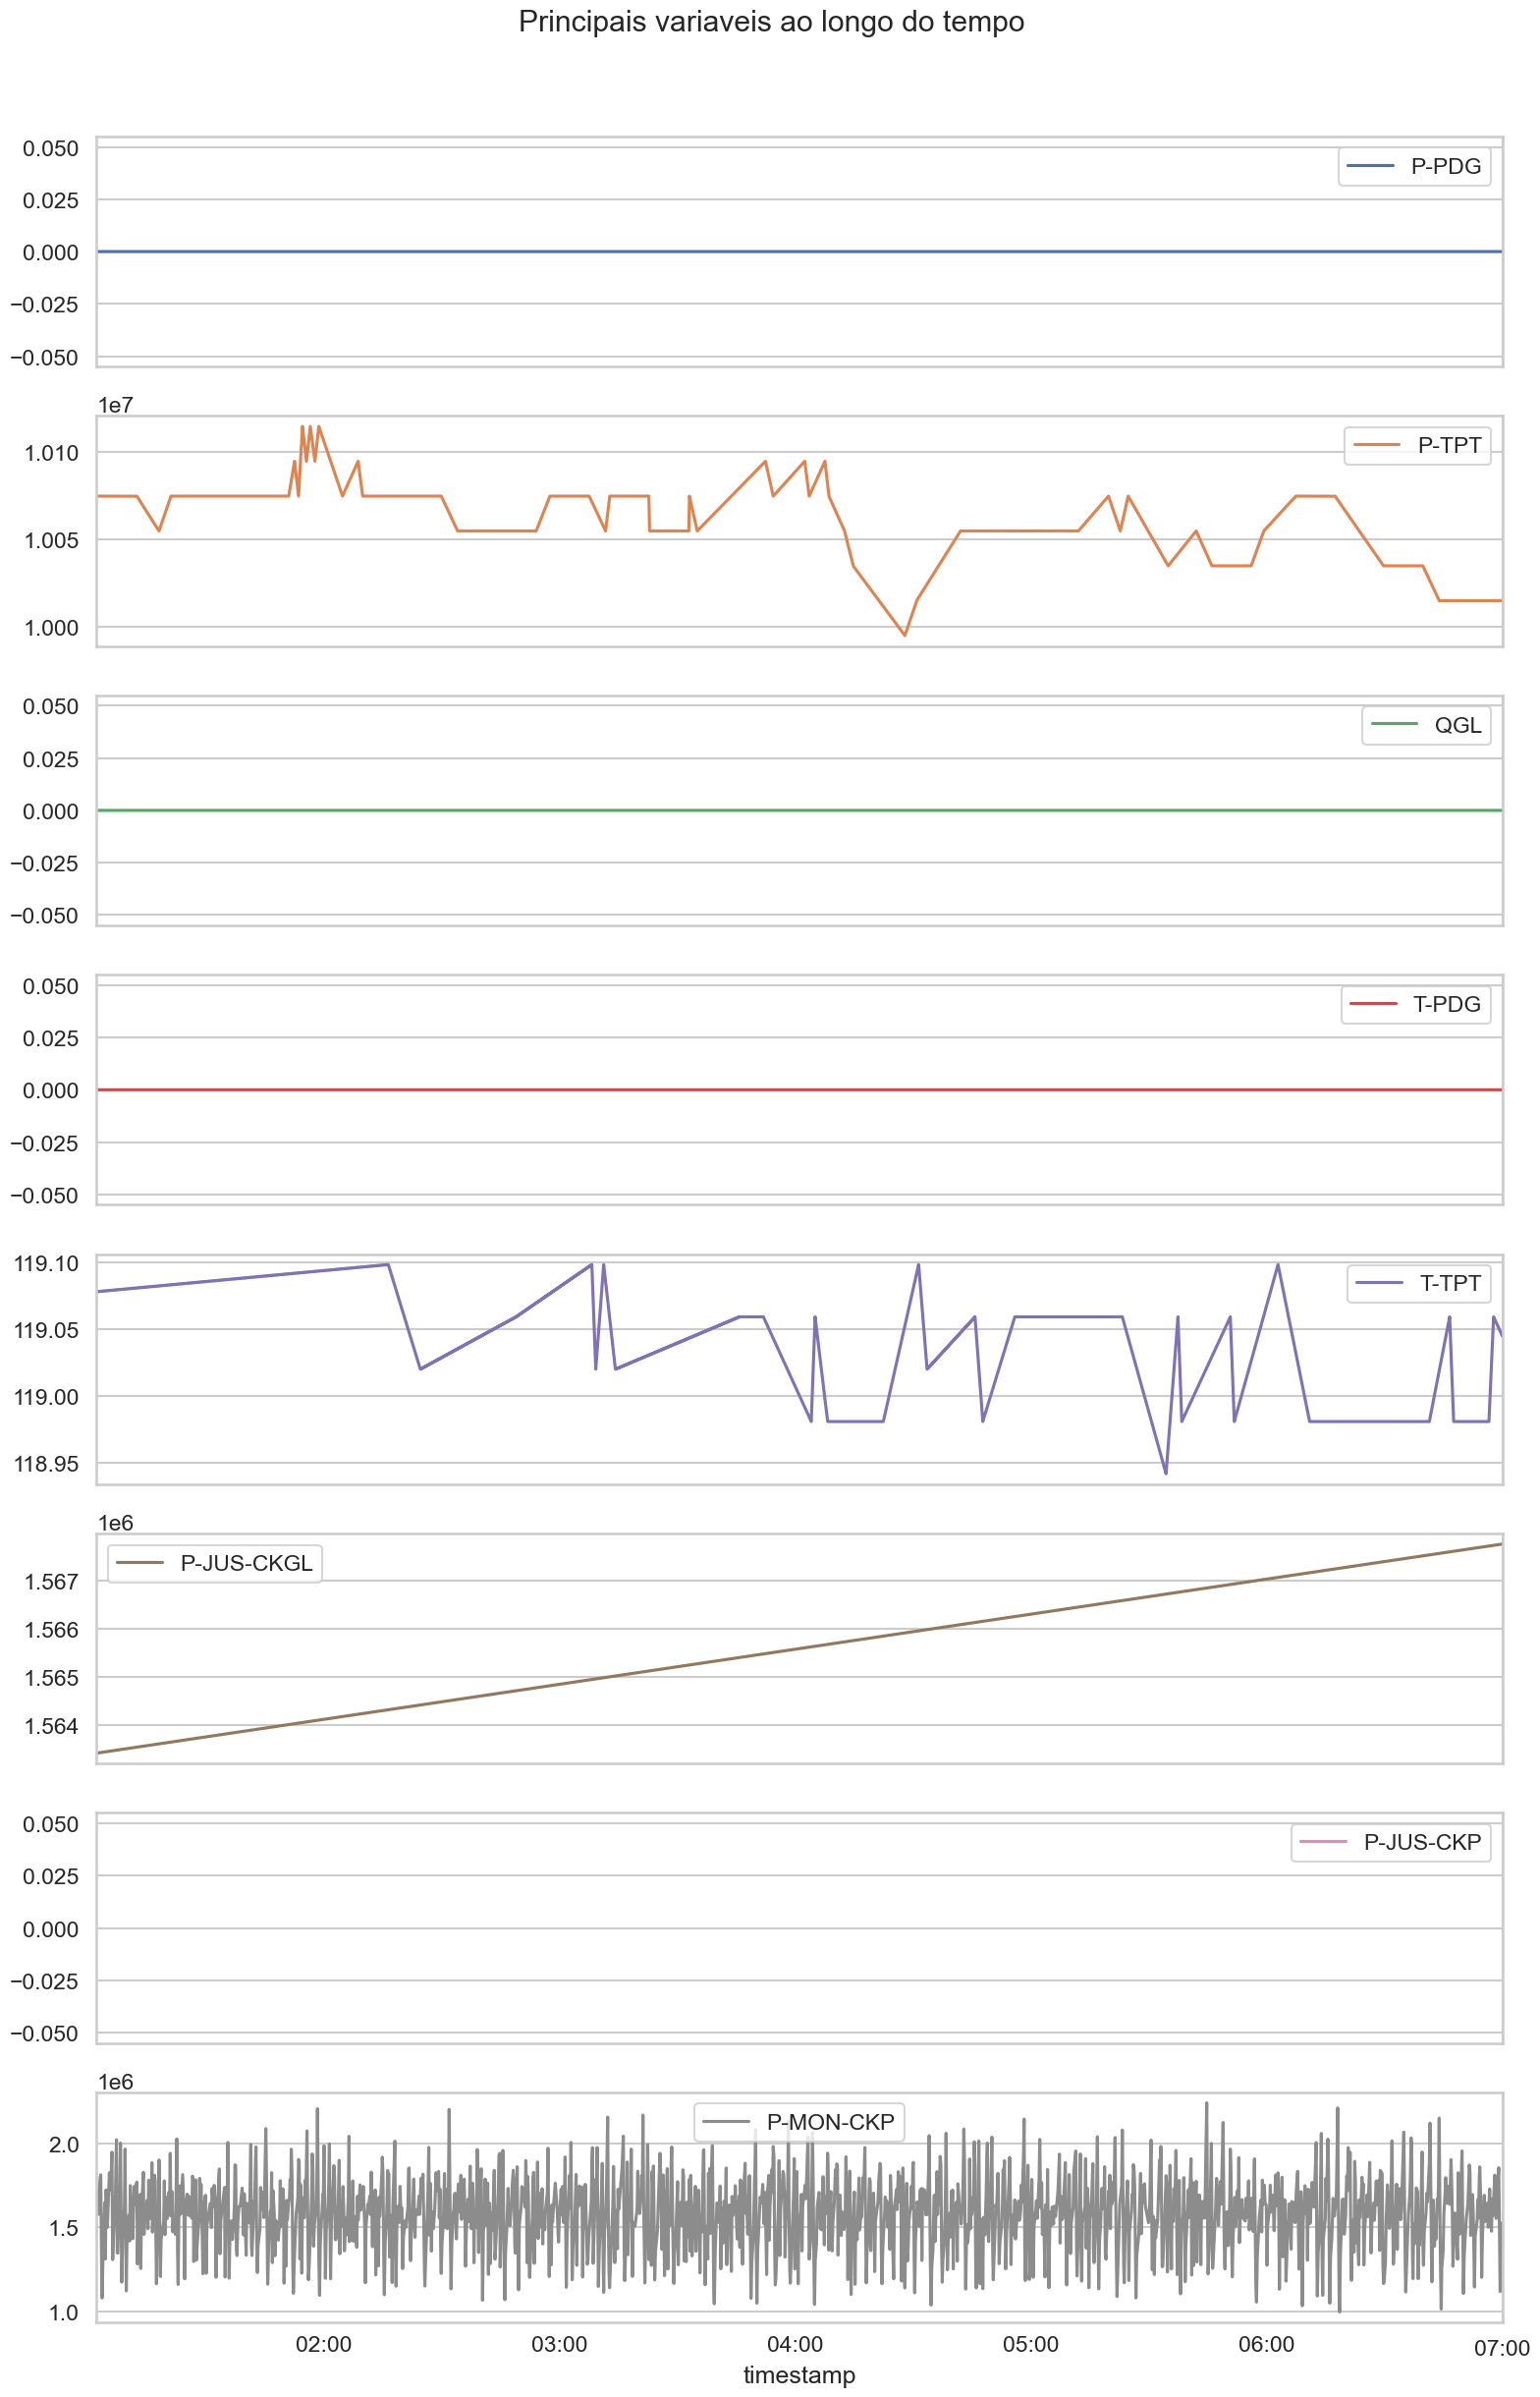

In [16]:
#plota cada sensor em um eixo proprio para facilitar leitura temporal
ax = df[selected_plot_columns].plot(subplots=True, figsize=(16, 3 * len(selected_plot_columns)), sharex=True)
plt.suptitle("Principais variaveis ao longo do tempo", y=1.02)
plt.tight_layout()
plt.show()


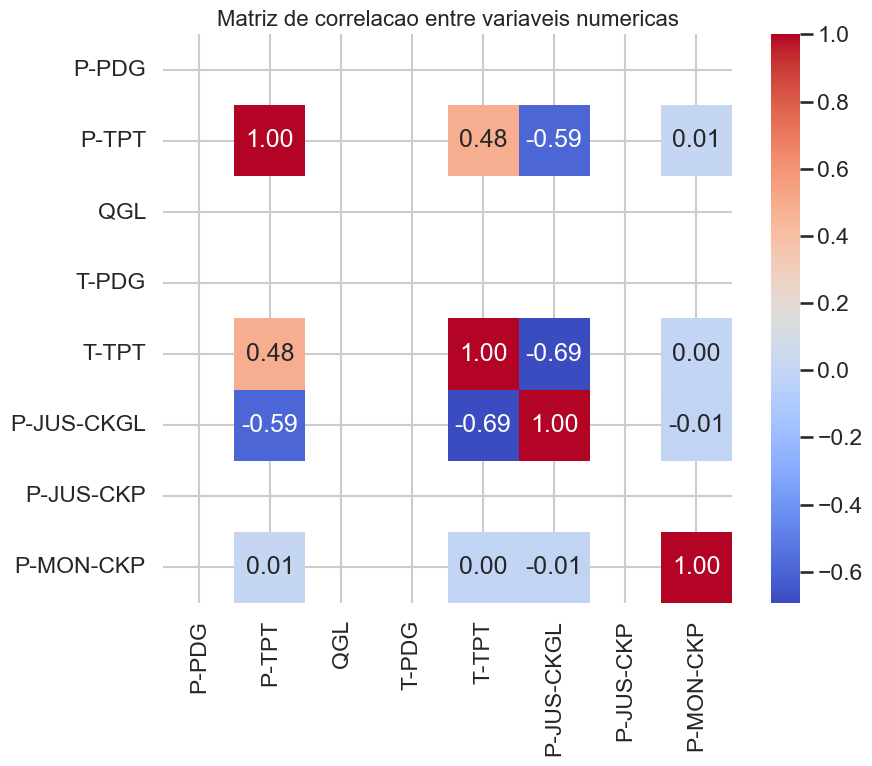

In [17]:
#restringe a correlacao a variaveis numericas relevantes
corr_columns = [col for col in priority_columns if col in numeric_columns]
if len(corr_columns) < 2:
    corr_columns = numeric_columns[: min(len(numeric_columns), 12)]

correlation_matrix = df[corr_columns].corr(numeric_only=True)

#o heatmap ajuda a enxergar dependencia linear entre sensores
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Matriz de correlacao entre variaveis numericas")
plt.tight_layout()
plt.show()


## 5. Fechamento

Esta etapa fica restrita a leitura e entendimento inicial dos dados. Os resultados desta execucao mostram uma serie com 21.474 observacoes, varios sensores totalmente ausentes e alguns sinais praticamente constantes, o que ja antecipa a necessidade de uma limpeza mais criteriosa antes de qualquer modelagem. No notebook seguinte, `2-pre-processamento.ipynb`, o pipeline passa a tratar esses pontos explicitamente: descarte de colunas inviaveis, separacao entre sinais analogicos e binarios, imputacao controlada, normalizacao/padronizacao e geracao dos artefatos que serao usados nas etapas de treino, validacao e teste.
